# 02 — Baseline × algoritmo adaptativo

## Formulação do problema

Duas ações estão disponíveis para o contato de marketing: **braços** `cellular` (índice 0) e `telephone` (índice 1). O **contexto** de cada cliente é o seu **segmento**, definido antes do contato a partir de duas informações conhecidas de antemão: a faixa etária (`jovem` ≤ 30, `adulto` 31–59, `sênior` ≥ 60) e se a campanha anterior teve sucesso (`poutcome == "success"`). Isso dá 6 segmentos: `jovem_sem_sucesso`, `jovem_com_sucesso`, `adulto_sem_sucesso`, `adulto_com_sucesso`, `senior_sem_sucesso`, `senior_com_sucesso`.

A **recompensa** é binária: 1 se o cliente contratou o produto (`y == "yes"`), 0 caso contrário.

Comparamos:

- **Baselines de regra fixa**: `ab_deterministico` (alterna os dois canais evento a evento, 50/50, sem aprender — equivalente a um teste A/B) e `sempre_telefone` / `melhor_historico` (sempre o mesmo canal).
- **Bandits contextuais**, que mantêm uma distribuição Beta por segmento × braço e a atualizam com **esquecimento**: um fator `gamma < 1` decai as contagens antigas a cada atualização. O esquecimento é necessário porque a base cobre vários meses de uma campanha real e **não é estacionária** — a conversão de cada canal muda ao longo do tempo (público-alvo, sazonalidade, ajustes de discurso etc.); sem esquecer o passado, o bandit ficaria "preso" a estimativas antigas.
  - `ts_contextual_desconto` (Thompson Sampling contextual com esquecimento) — **política principal, pré-registrada antes de olhar o teste**.
  - `ts_contextual_padrao` (mesma política, sem esquecimento, `gamma = 1`) e `ts_sem_contexto_desconto` (com esquecimento, mas um único "segmento" para toda a base) — ablações para isolar o efeito do desconto e do contexto.
  - `eg_contextual_desconto` (ε-Greedy contextual com esquecimento) — alternativa mais simples de exploração/explotação.

A **avaliação** é feita por **replay off-policy** dos logs históricos: um evento só é aproveitado quando a política teria escolhido o mesmo canal que foi de fato usado (`matched`). Como os dois canais não foram usados com a mesma frequência em cada bloco temporal, usamos **SNIPS** (*Self-Normalized Inverse Propensity Scoring*): pondera cada evento aproveitado pelo inverso da propensão do canal logado naquele bloco e normaliza pela soma dos pesos — isso estima a conversão que a política teria obtido em produção, em vez da simples média bruta dos eventos aproveitados (que fica enviesada a favor do canal usado mais raramente no log).

Os eventos de avaliação são divididos cronologicamente ao meio: a primeira metade é usada como **validação** (escolha dos hiperparâmetros `gamma`/`epsilon`) e a segunda metade como **teste** (métricas finais, nunca usada para ajustar nada).

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display

from datathon.data import clean, evaluation_set, load_raw
from datathon.evaluation import replay, snips
from datathon.policies import AlternatingAB, DiscountedThompsonSampling, FixedArm
from datathon.train import EvalData, run_many, summarize

ev = evaluation_set(clean(load_raw()))
data = EvalData.from_frame(ev)
print(len(ev), int(data.test_mask.sum()))

29040 14520


## Por que não o replay ingênuo

Ao aproveitar só os eventos em que a política escolheu o mesmo canal do log (`matched`), a média bruta das recompensas desses eventos ("replay ingênuo") fica enviesada: o canal usado com menor frequência no log tende a aparecer em blocos/condições diferentes do canal majoritário, então a média bruta não estima a conversão que a política teria em produção. O SNIPS corrige esse viés ponderando pelo inverso da propensão. Comparamos os dois abaixo, no conjunto de teste, para duas políticas simples de referência:

In [2]:
naive = {}
for nome, pol in {"ab": AlternatingAB(), "sempre_celular": FixedArm(0)}.items():
    r = replay(pol, data.segments, data.arms, data.rewards, np.random.default_rng(0))
    naive[nome] = {"ingenuo": data.rewards[r.matched & data.test_mask].mean(),
                   "snips": snips(r.matched, data.rewards, data.propensities, data.test_mask)}
pd.DataFrame(naive).T

,ingenuo,snips
ab,0.234235,0.200169
sempre_celular,0.237029,0.243986


## Baseline (regra fixa)

O baseline pré-registrado é o `ab_deterministico`: alterna os canais evento a evento, sem aprender (o que a área de marketing já faria com um teste A/B simples). Comparamos também com `sempre_telefone`, uma regra fixa mais fraca. Como as duas são determinísticas, uma única seed já é suficiente — não há variância de amostragem da política em si.

In [3]:
baseline_specs = {"ab_deterministico": AlternatingAB, "sempre_telefone": lambda: FixedArm(1)}
baseline_summaries = {nome: summarize(run_many(factory, data, range(1)), data)
                       for nome, factory in baseline_specs.items()}
pd.DataFrame(baseline_summaries).T.drop(columns="snips_by_segment")

,snips_mean,snips_std,pseudo_regret_final,best_arm_share,accepted_events,ess
ab_deterministico,0.200169,0.0,749.517935,0.5,7279.0,2325.380809
sempre_telefone,0.15022,0.0,1411.720496,0.082645,1433.0,1263.624496


## Algoritmo adaptativo (1 seed ao vivo)

Rodamos aqui, ao vivo, uma única seed da política principal (`ts_contextual_desconto`), usando o `gamma` já escolhido na validação e salvo em `reports/metrics.json` por `python -m datathon.train`. Os resultados robustos — 30 seeds de teste com intervalo de confiança por bootstrap de blocos — estão na próxima seção, carregados diretamente do experimento já executado.

In [4]:
metrics = json.loads(Path("../reports/metrics.json").read_text(encoding="utf-8"))
gamma = metrics["selected"]["gamma_ts"]
r = replay(DiscountedThompsonSampling(gamma=gamma), data.segments, data.arms, data.rewards,
           np.random.default_rng(0))
print(gamma, snips(r.matched, data.rewards, data.propensities, data.test_mask))

0.99 0.210968926359497


## Resultados completos (30 seeds, `python -m datathon.train`)

O experimento completo — grade de hiperparâmetros na validação, 30 seeds de teste, bootstrap por blocos para o intervalo de confiança, figuras e o artefato do modelo servido — já foi executado por `python -m datathon.train` e salvo em `reports/metrics.json`, `reports/figures/` e `models/policy.json`. Carregamos os resultados salvos abaixo em vez de reexecutar o treino completo dentro do notebook.

### Seleção de hiperparâmetros (validação)

In [5]:
pd.DataFrame(metrics["validation"])

,policy,gamma,epsilon,snips_validacao
0,ts_contextual,1.000,NaN,0.059744
1,ts_contextual,0.999,NaN,0.068741
2,ts_contextual,0.995,NaN,0.068485
3,ts_contextual,0.990,NaN,0.070875
4,eg_contextual,1.000,0.05,0.058425
5,eg_contextual,0.999,0.05,0.074415
6,eg_contextual,0.995,0.05,0.068478
7,eg_contextual,0.990,0.05,0.067889
8,eg_contextual,1.000,0.10,0.057843
9,eg_contextual,0.999,0.10,0.074837


### Métricas de teste (30 seeds) e comparação com o baseline

`diff`, `ci_low` e `ci_high` são a diferença de SNIPS (política − baseline) e o intervalo de confiança de 95% por bootstrap de blocos.

In [6]:
tabela = pd.DataFrame(metrics["policies"]).T.drop(columns="snips_by_segment")
comp = pd.DataFrame(metrics["comparison_vs_baseline"]).T
tabela.join(comp).sort_values("snips_mean", ascending=False)

,snips_mean,snips_std,pseudo_regret_final,best_arm_share,accepted_events,ess,diff,ci_low,ci_high
melhor_historico,0.243986,0.0,87.58478,0.917355,13087.0,13027.659813,0.043817,0.020548,0.089947
ts_sem_contexto_desconto,0.218736,0.003588,475.846304,0.557679,7568.833333,2342.044096,0.018576,0.003062,0.051976
ts_contextual_desconto,0.2071,0.005265,614.268166,0.4939,6772.1,2085.49516,0.006906,-0.005700,0.031486
ab_deterministico,0.200169,0.0,749.517935,0.5,7279.0,2325.380809,NaN,NaN,NaN
ts_contextual_padrao,0.199646,0.018891,735.560801,0.459729,6408.133333,2850.119326,-0.000731,-0.013884,0.010186
eg_contextual_desconto,0.183849,0.01262,909.767654,0.297167,4014.2,1547.32474,-0.016492,-0.027128,-0.006469
sempre_telefone,0.15022,0.0,1411.720496,0.082645,1433.0,1263.624496,-0.049949,-0.098894,-0.030315


### SNIPS por segmento

In [7]:
pd.DataFrame({k: v["snips_by_segment"] for k, v in metrics["policies"].items()})

,ab_deterministico,sempre_telefone,melhor_historico,ts_contextual_desconto,ts_contextual_padrao,ts_sem_contexto_desconto,eg_contextual_desconto
jovem_sem_sucesso,0.182463,0.133441,0.246310,0.192995,0.203135,0.211765,0.149465
jovem_com_sucesso,0.673170,0.638006,0.636900,0.640610,0.638248,0.660739,0.680054
adulto_sem_sucesso,0.141410,0.109531,0.164040,0.144912,0.128304,0.147761,0.124095
adulto_com_sucesso,0.649192,0.628441,0.662914,0.660597,0.661309,0.679536,0.664678
senior_sem_sucesso,0.326632,0.232905,0.393223,0.338971,0.372539,0.323312,0.371677
senior_com_sucesso,0.744813,0.849297,0.759511,0.783813,0.784929,0.767190,0.806248


### Figuras

`conversao_snips`: SNIPS de teste por política (± desvio padrão entre seeds), com a linha tracejada marcando o baseline A/B. `pseudo_regret`: regret acumulado ao longo dos eventos de teste (quanto menor, melhor). `escolha_melhor_braco`: fração de escolhas no braço de maior conversão do bloco, em janela móvel de 1000 eventos.

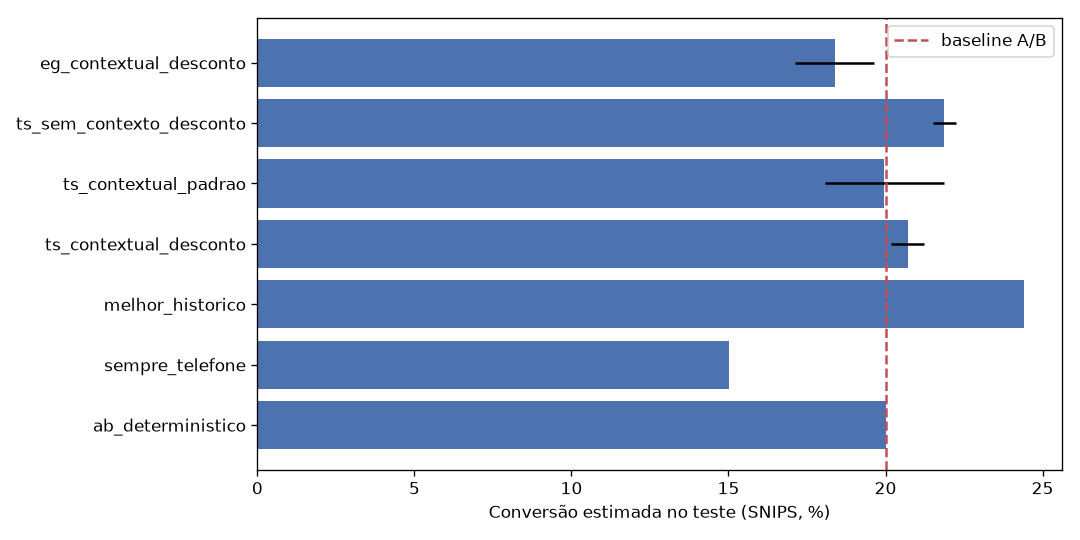

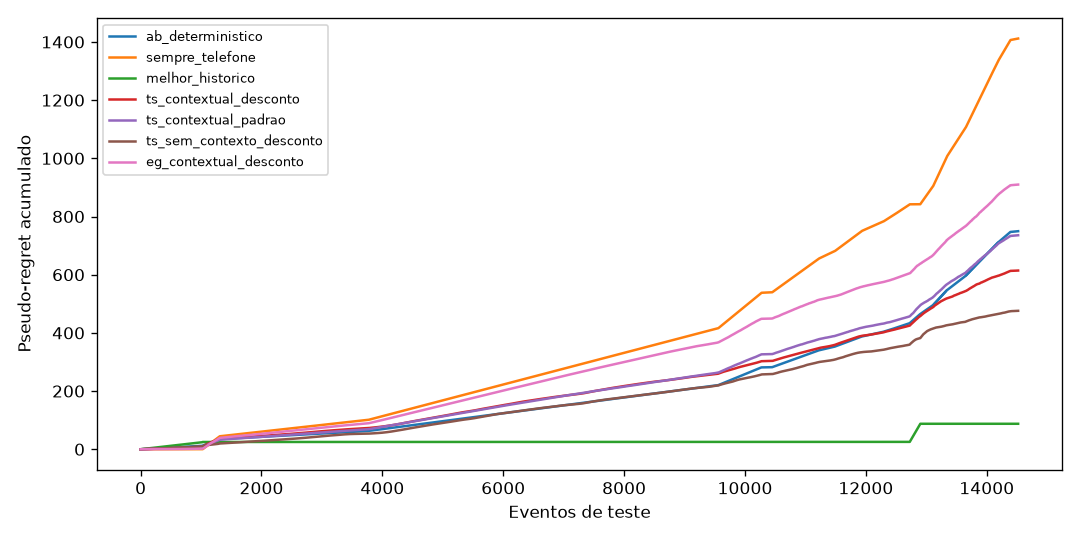

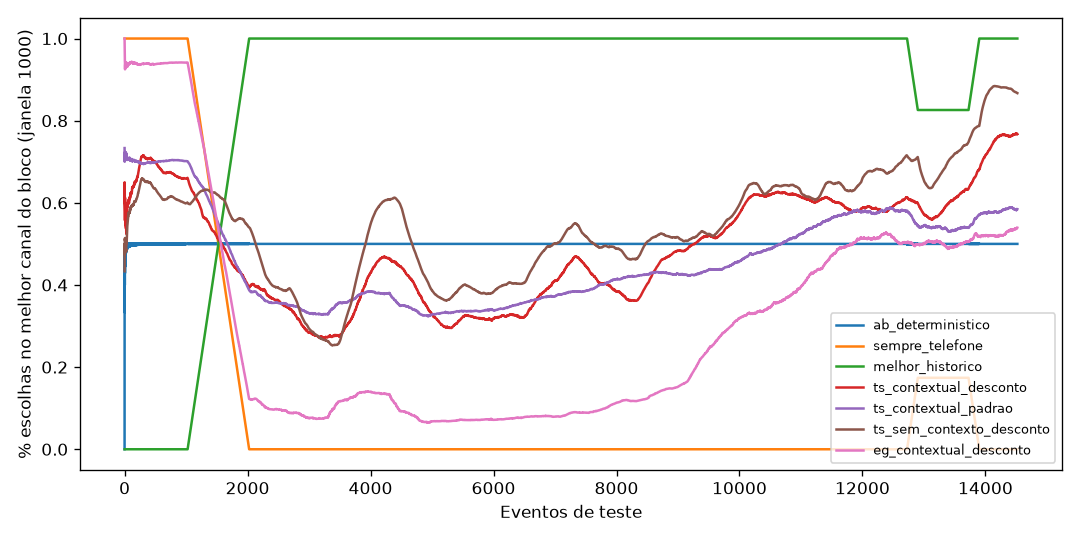

In [8]:
for f in ["conversao_snips", "pseudo_regret", "escolha_melhor_braco"]:
    display(Image(f"../reports/figures/{f}.png"))

## Golden Set

Conjunto de 5 clientes fictícios (um por segmento mais relevante) usado para inspecionar manualmente se as recomendações do modelo servido (`models/policy.json`) fazem sentido de negócio. Para o cliente sênior com sucesso anterior a amostra histórica é pequena (13 telefonemas vs. 191 celulares), então não fixamos um canal esperado — validamos apenas que o modelo reporta baixa confiança (0,05 < P(celular melhor) < 0,95).

In [9]:
from datathon.features import segment_of
from datathon.golden_set import GOLDEN_SET
from datathon.model import PosteriorModel

model = PosteriorModel.load("../models/policy.json")
linhas = []
for c in GOLDEN_SET:
    seg = segment_of(c["age"], c["poutcome"])
    rec = model.recommend(seg)
    p = model.prob_cellular_better(seg)
    ok = (0.05 < p < 0.95) if c["expected_channel"] is None else rec == c["expected_channel"]
    linhas.append({"cliente": c["descricao"], "segmento": seg,
                   "canais": "cellular, telephone", "recomendado": rec,
                   "taxa_estimada": model.estimated_rates(seg), "P(celular melhor)": round(p, 3),
                   "esperado": c["expected_channel"] or "baixa confiança",
                   "faz sentido?": "sim" if ok else "NÃO", "justificativa": c["justificativa"]})
pd.DataFrame(linhas)

,cliente,segmento,canais,recomendado,taxa_estimada,P(celular melhor),esperado,faz sentido?,justificativa
0,"Jovem de 25 anos, nunca participou de campanha",jovem_sem_sucesso,"cellular, telephone",cellular,"{'cellular': 0.42353613713669075, 'telephone':...",1.000,cellular,sim,No histórico do segmento o celular converte be...
1,"Adulto de 45 anos, nunca participou de campanha",adulto_sem_sucesso,"cellular, telephone",cellular,"{'cellular': 0.41526023318182786, 'telephone':...",0.971,cellular,sim,Maior segmento da base; celular com conversão ...
2,Adulto de 40 anos que aceitou a campanha anterior,adulto_com_sucesso,"cellular, telephone",cellular,"{'cellular': 0.8127301623370526, 'telephone': ...",0.806,cellular,sim,"Conversão alta nos dois canais, com vantagem d..."
3,Sênior de 70 anos cuja campanha anterior falhou,senior_sem_sucesso,"cellular, telephone",cellular,"{'cellular': 0.4294510762391912, 'telephone': ...",0.655,cellular,sim,Celular com conversão maior no segmento sênior...
4,Sênior de 65 anos que aceitou a campanha anterior,senior_com_sucesso,"cellular, telephone",telephone,"{'cellular': 0.7610696866144202, 'telephone': ...",0.371,baixa confiança,sim,"Telefone 84,6% (n=13) vs. celular 75,4% (n=191..."


## Conclusões

Os números abaixo vêm de `reports/metrics.json` (30 seeds de teste; intervalo de confiança de 95% por bootstrap de blocos, 1.000 reamostragens), a saída de `python -m datathon.train` já registrada e não reexecutada aqui.

1. **A política principal, pré-registrada (`ts_contextual_desconto`), tem estimativa pontual melhor que o baseline A/B (20,71% vs. 20,02% de SNIPS, +0,69 p.p.), mas o intervalo de confiança de 95% da diferença inclui zero: [−0,57; +3,15] p.p.** O critério de sucesso definido antes de olhar o teste — bater o baseline com significância estatística — **não foi atingido**. Mantivemos o desenho pré-registrado (o TS contextual continua sendo o modelo servido) e reportamos o resultado como saiu, sem ajustar a política depois de ver o teste.
2. Isso não quer dizer que o mecanismo de bandit não funcione: a ablação sem contexto (`ts_sem_contexto_desconto` — mesmo esquecimento, mas um único "segmento" para toda a base) supera o baseline com significância (21,87% vs. 20,02%, +1,86 p.p., IC [+0,31; +5,20] p.p.). Um indício de que, com o volume de dados desta base, dividir em 6 segmentos aumenta a variância de estimativa mais do que o ganho de personalização compensa nesta escala — um trade-off entre personalização e quantidade de dados disponível por segmento.
3. **Há indício (não prova estatística) de que o esquecimento ajuda**: a estimativa pontual de `ts_contextual_desconto` (`gamma = 0,99`) é maior que a de `ts_contextual_padrao` (`gamma = 1`), mas os IC 95% de ambas cruzam zero (+0,69 p.p., IC [−0,57; +3,15] p.p. vs. −0,07 p.p., IC [−1,39; +1,02] p.p.) e a diferença entre as duas não foi testada diretamente. É consistente com a base não sendo estacionária, mas os dados atuais não permitem afirmar isso com confiança estatística.
4. Ninguém supera `melhor_historico` (sempre celular, 24,40% de SNIPS). **Essa não é uma política retrospectiva**: é uma regra fixa escolhida com o 1º bloco de avaliação (jul/2008), antes mesmo do início do teste (nov/2008) — ou seja, já poderia ter sido aplicada em tempo real. Ela vence todas as políticas adaptativas porque, neste dataset, o celular é o melhor canal em ≈92% dos eventos de teste e o melhor braço quase não muda ao longo do tempo: aprender/explorar custa tráfego sem retorno quando a resposta certa já é conhecida de largada (ver a curva de pseudo-regret acima). O bandit contextual se justifica quando o melhor canal é desconhecido a priori ou muda ao longo do tempo.
5. `eg_contextual_desconto` (ε-Greedy contextual com desconto) fica abaixo do baseline (18,38%, −1,65 p.p., IC [−2,71; −0,65] p.p. — significativo na direção errada), pior que o Thompson Sampling contextual equivalente. Neste problema, a exploração aleatória do ε-Greedy é menos eficiente que a exploração guiada pela incerteza da posterior do Thompson Sampling.
6. **A % no melhor braço do TS servido (49,4%, próxima do que um A/B 50/50 teria por acaso) é em parte artefato do replay off-policy**: no replay, o telefone só recebe atualização de crença quando a política o escolhe **e** o log também registra telefone (≈10% dos eventos de teste), então suas contagens ficam perto do prior `Beta(1,1)` e o TS acaba escolhendo telefone bem mais do que faria com feedback completo (ver Limitações).
7. **Limitações**: (i) a propensão do canal logado é aproximada por bloco temporal (mês), não por evento individual, então pode haver viés residual de propensão não capturado; (ii) o experimento cobre um único produto (depósito a prazo) e uma única decisão de canal, não generaliza automaticamente para outras ofertas; (iii) os 6 segmentos foram definidos olhando a base inteira, não há um conjunto totalmente fora da amostra para validar a segmentação; (iv) o bootstrap por percentil pode ter cobertura um pouco abaixo do nominal com poucos blocos, então os intervalos de confiança reportados podem estar ligeiramente otimistas (mais estreitos que o real); (v) a sobre-exploração do braço raro (item 6) é em parte artefato do replay — em produção toda escolha gera feedback real; próximos passos a validar numa nova rodada pré-registrada: prior mais informativo (ex.: `Beta` com média ≈11%, a conversão global) ou desconto `gamma` aplicado só ao braço efetivamente observado.